In [89]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [90]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (20,5)
plt.rcParams['figure.dpi'] = 250
sns.set_style('darkgrid')
%matplotlib inline

In [91]:
df = pd.read_csv('processed_stock_data.csv')
df


,Date,Open,High,Low,Close,Volume,50-day MA,200-day MA,Close_diff,lag_1,lag_7,rolling_mean_7,rolling_std_7
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,75555200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,65005500,NaN,NaN,0.315716,58.747143,NaN,NaN,NaN
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,67817400,NaN,NaN,0.655712,59.062859,NaN,NaN,NaN
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,79573200,NaN,NaN,0.624286,59.718571,NaN,NaN,NaN
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,98506100,NaN,NaN,-0.095714,60.342857,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006,2019-12-23,280.529999,284.250000,280.369995,283.809289,24643000,259.670586,216.528297,4.369287,279.440002,271.459991,279.775608,2.524879
2007,2019-12-24,284.150718,284.890015,280.977848,283.809289,12119700,260.629372,217.042793,0.000000,283.809289,275.149994,281.012650,1.932721
2008,2019-12-26,284.150718,288.448204,280.977848,283.809289,23280300,261.599157,217.553289,0.000000,283.809289,279.859985,281.576836,2.108589
2009,2019-12-27,284.150718,288.448204,280.977848,283.809289,36566500,262.587943,218.053686,0.000000,283.809289,280.410004,282.062448,2.185120


In [92]:
df.dtypes

Date               object
Open              float64
High              float64
Low               float64
Close             float64
Volume              int64
50-day MA         float64
200-day MA        float64
Close_diff        float64
lag_1             float64
lag_7             float64
rolling_mean_7    float64
rolling_std_7     float64
dtype: object

In [93]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Open,High,Low,Close,Volume,50-day MA,200-day MA,Close_diff,lag_1,lag_7,rolling_mean_7,rolling_std_7
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,75555200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,65005500,NaN,NaN,0.315716,58.747143,NaN,NaN,NaN
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,67817400,NaN,NaN,0.655712,59.062859,NaN,NaN,NaN
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,79573200,NaN,NaN,0.624286,59.718571,NaN,NaN,NaN
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,98506100,NaN,NaN,-0.095714,60.342857,NaN,NaN,NaN


In [94]:
df.dtypes

Date              datetime64[ns]
Open                     float64
High                     float64
Low                      float64
Close                    float64
Volume                     int64
50-day MA                float64
200-day MA               float64
Close_diff               float64
lag_1                    float64
lag_7                    float64
rolling_mean_7           float64
rolling_std_7            float64
dtype: object

In [95]:
df.head()

,Date,Open,High,Low,Close,Volume,50-day MA,200-day MA,Close_diff,lag_1,lag_7,rolling_mean_7,rolling_std_7
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,75555200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,65005500,NaN,NaN,0.315716,58.747143,NaN,NaN,NaN
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,67817400,NaN,NaN,0.655712,59.062859,NaN,NaN,NaN
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,79573200,NaN,NaN,0.624286,59.718571,NaN,NaN,NaN
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,98506100,NaN,NaN,-0.095714,60.342857,NaN,NaN,NaN


In [96]:
df = df[["Date", 'Close']]
df

,Date,Close
0,2012-01-03,58.747143
1,2012-01-04,59.062859
2,2012-01-05,59.718571
3,2012-01-06,60.342857
4,2012-01-09,60.247143
...,...,...
2006,2019-12-23,283.809289
2007,2019-12-24,283.809289
2008,2019-12-26,283.809289
2009,2019-12-27,283.809289


In [97]:
#Set 'Date' as Index
df.set_index('Date', inplace=True)
df

,Close
Date,
2012-01-03,58.747143
2012-01-04,59.062859
2012-01-05,59.718571
2012-01-06,60.342857
2012-01-09,60.247143
...,...
2019-12-23,283.809289
2019-12-24,283.809289
2019-12-26,283.809289


<Axes: xlabel='Date'>

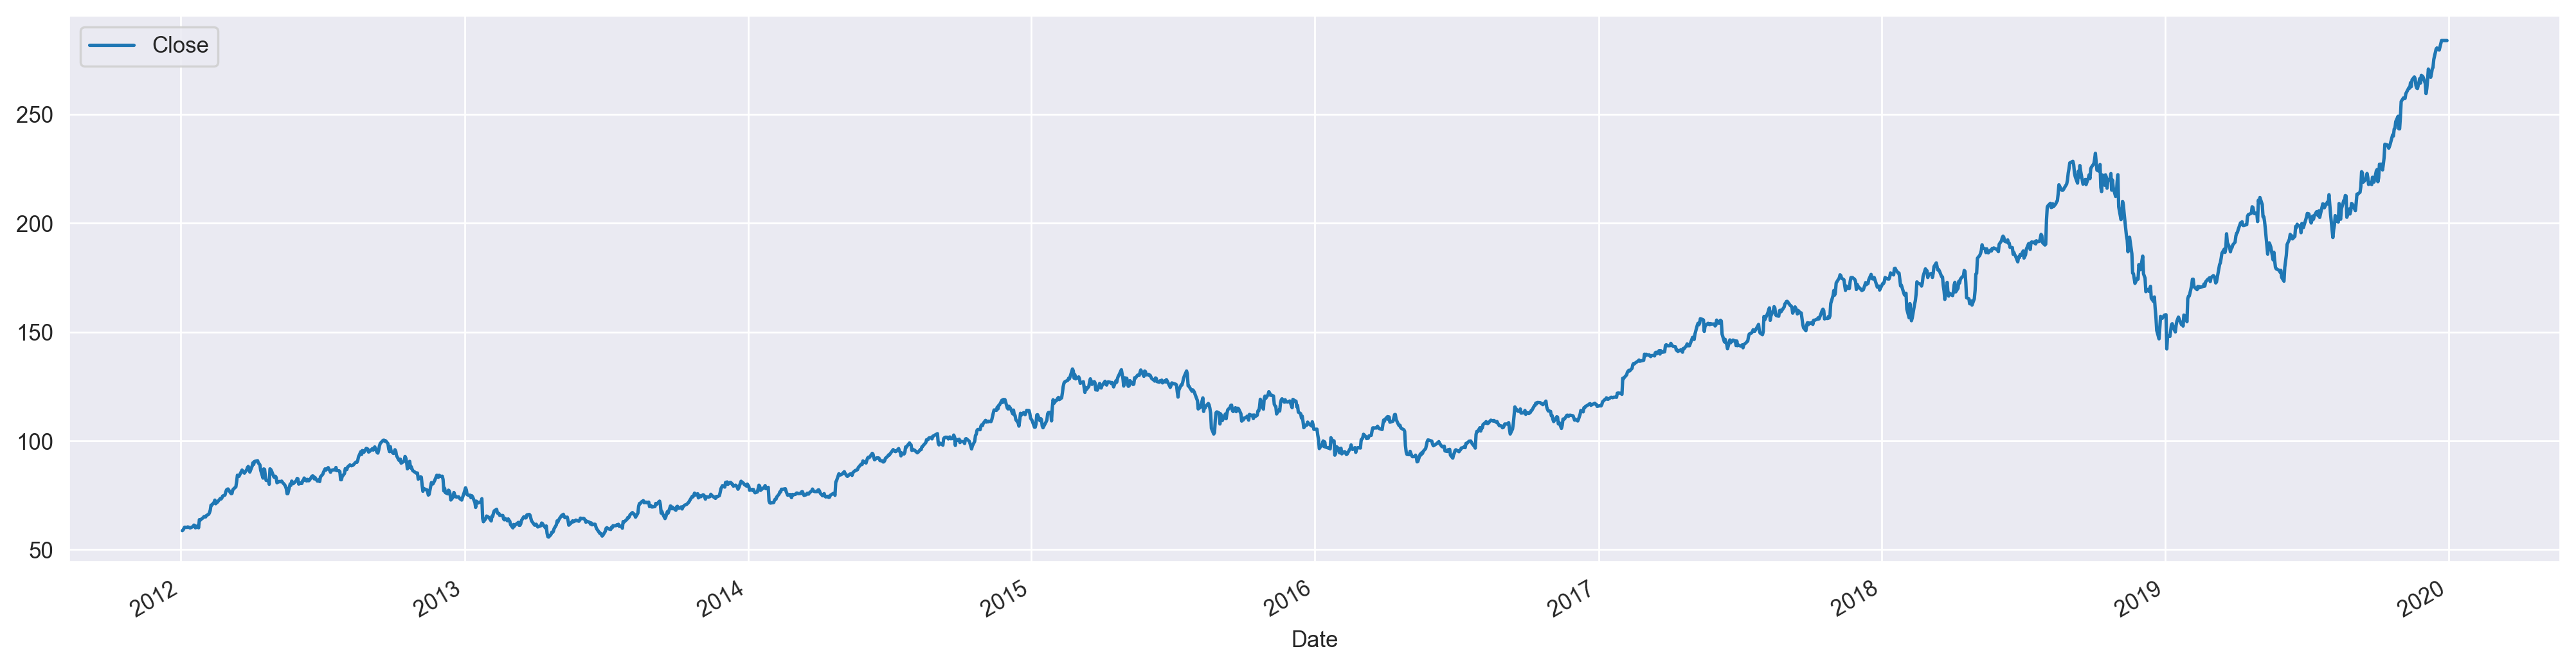

In [98]:
#Check stationarity of the data
df.plot()

In [99]:
result = adfuller(df['Close'].dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])

if result[1] < 0.05:
    print("Data is stationary (Reject H0)")
else:
    print("Data is NOT stationary (Fail to reject H0)")

ADF Statistic: 0.984317559130625
p-value: 0.9940976935123645
Critical Values: {'1%': -3.433622218212895, '5%': -2.8629854902259004, '10%': -2.5675395171404802}
Data is NOT stationary (Fail to reject H0)


In [100]:
df['Close_diff'] = df['Close'] - df['Close'].shift(1)

In [101]:
result = adfuller(df['Close_diff'].dropna())
print("p-value after differencing:", result[1])

p-value after differencing: 9.106620961204917e-26


In [102]:
df = df.dropna(subset=['Close_diff'])

In [103]:
df.isnull().sum()

Close         0
Close_diff    0
dtype: int64

**Arima model building**
- ARIMA is composed of 3 terms(Auto-Regression(p) + Integrated(d) + Moving-Average(q))
- First, we need to find out the order of arima model.

In [104]:
#find out order of arima

In [105]:
order = auto_arima(df['Close_diff'])

In [106]:
order

ARIMA(order=(2, 0, 0), scoring_args={}, suppress_warnings=True)

In [107]:
df.shape

(2010, 2)

In [108]:
#Split the data
train = df.iloc[:-30]
test = df.iloc[-30:]

In [109]:
test

,Close,Close_diff
Date,,
2019-11-15,265.760010,3.119995
2019-11-18,267.100006,1.339996
2019-11-19,266.290009,-0.809997
2019-11-20,263.190002,-3.100007
2019-11-21,262.010010,-1.179992
2019-11-22,261.779999,-0.230011
2019-11-25,266.369995,4.589996
2019-11-26,264.290009,-2.079986
2019-11-27,267.839996,3.549987


In [110]:
train

,Close,Close_diff
Date,,
2012-01-04,59.062859,0.315716
2012-01-05,59.718571,0.655712
2012-01-06,60.342857,0.624286
2012-01-09,60.247143,-0.095714
2012-01-10,60.462856,0.215713
...,...,...
2019-11-08,260.140015,0.710022
2019-11-11,262.200012,2.059997
2019-11-12,261.959991,-0.240021


In [111]:
#Arima model
model = ARIMA(train['Close_diff'], order=(2, 0, 0)).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             Close_diff   No. Observations:                 1980
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -4287.870
Date:                Fri, 14 Mar 2025   AIC                           8583.740
Time:                        01:28:52   BIC                           8606.103
Sample:                             0   HQIC                          8591.955
                               - 1980                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1029      0.047      2.211      0.027       0.012       0.194
ar.L1          0.0107      0.015      0.714      0.475      -0.019       0.040
ar.L2         -0.0570      0.016     -3.497      0.000      -0.089      -0.025
sigma2         4.4518      0.070     63.633      0.000       4.315       4.589
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              3787.79
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               5.10   Skew:                            -0.49
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.71
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [112]:
#Evaluating the model
len(test)

30

In [113]:
ypred = model.predict(start =1981, end = 2010)
ypred

1981    0.211499
1982    0.113107
1983    0.096862
1984    0.102300
1985    0.103285
1986    0.102985
1987    0.102926
1988    0.102942
1989    0.102946
1990    0.102945
1991    0.102945
1992    0.102945
1993    0.102945
1994    0.102945
1995    0.102945
1996    0.102945
1997    0.102945
1998    0.102945
1999    0.102945
2000    0.102945
2001    0.102945
2002    0.102945
2003    0.102945
2004    0.102945
2005    0.102945
2006    0.102945
2007    0.102945
2008    0.102945
2009    0.102945
2010    0.102945
Name: predicted_mean, dtype: float64

In [114]:
print(np.sqrt(mean_squared_error(test['Close_diff'], ypred)))

2.667561526800857


In [115]:
print(test['Close_diff'].describe())

count    30.000000
mean      0.705642
std       2.647456
min      -4.709992
25%      -0.650010
50%       0.140000
75%       2.912491
max       5.130004
Name: Close_diff, dtype: float64


In [116]:
def check_stationarity(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("✅ The data is stationary")
    else:
        print("❌ The data is NOT stationary. Differencing is needed.")


In [117]:
check_stationarity(test["Close_diff"])

ADF Statistic: -5.029000824267614
p-value: 1.9439660831964397e-05
✅ The data is stationary
